In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor, XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import RandomizedSearchCV, train_test_split

#### Load cleaned data

In [2]:
df = pd.read_csv('data/f1_laps_clean.csv')

In [3]:
df.columns

Index(['Driver', 'Team', 'Year', 'Race', 'Sector1Time', 'Sector2Time',
       'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime',
       'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'Stint',
       'LapTime', 'LapNumber', 'Position', 'Compound', 'TyreLife', 'FreshTyre',
       'TrackStatus', 'AirTemp', 'Humidity', 'Pressure', 'Rainfall',
       'TrackTemp', 'WindDirection', 'WindSpeed', 'Speed_Mean', 'Speed_Max',
       'Speed_Std', 'RPM_Mean', 'Throttle_Mean', 'Throttle_Std', 'Brake_Mean',
       'Gear_Mean', 'Distance_Total', 'DRS_active_pct', 'LapsTilPit'],
      dtype='object')

#### Filter out wet tyres

In [4]:
df['Rainfall'].value_counts()

Rainfall
False    78539
True      3662
Name: count, dtype: int64

In [5]:
df[df['Rainfall']==1]['Compound'].value_counts()

Compound
INTERMEDIATE    2337
MEDIUM           445
HARD             421
SOFT             349
WET              110
Name: count, dtype: int64

In [6]:
df['Compound'].value_counts()

Compound
HARD            37613
MEDIUM          29325
SOFT            10292
INTERMEDIATE     4834
WET               137
Name: count, dtype: int64

In [7]:
df[(df['Compound']=='INTERMEDIATE') | (df['Compound']=='WET')]['Rainfall'].value_counts()

Rainfall
False    2524
True     2447
Name: count, dtype: int64

In [8]:
df = df[~((df['Compound']=='INTERMEDIATE') | (df['Compound']=='WET'))]

In [9]:
df['Rainfall'].value_counts()

Rainfall
False    76015
True      1215
Name: count, dtype: int64

In [10]:
df['Compound'].value_counts()

Compound
HARD      37613
MEDIUM    29325
SOFT      10292
Name: count, dtype: int64

#### Encode and standardize features

In [11]:
df.dtypes

Driver                 object
Team                   object
Year                    int64
Race                   object
Sector1Time            object
Sector2Time            object
Sector3Time            object
Sector1SessionTime     object
Sector2SessionTime     object
Sector3SessionTime     object
SpeedI1               float64
SpeedI2               float64
SpeedFL               float64
Stint                 float64
LapTime                object
LapNumber             float64
Position              float64
Compound               object
TyreLife              float64
FreshTyre                bool
TrackStatus             int64
AirTemp               float64
Humidity              float64
Pressure              float64
Rainfall                 bool
TrackTemp             float64
WindDirection         float64
WindSpeed             float64
Speed_Mean            float64
Speed_Max             float64
Speed_Std             float64
RPM_Mean              float64
Throttle_Mean         float64
Throttle_S

In [12]:
# Turn bool values into int
df['FreshTyre'] = df['FreshTyre'].astype(int)
df['Rainfall'] = df['Rainfall'].astype(int)

In [13]:
ordinal_cols = ['Stint', 'Position']  # leave as is
label = ['LapsTilPit']

categorical_cols = ['Driver', 'Team', 'Race', 'TrackStatus', 'Compound']

numerical_cols = ['LapTimeSeconds', 'LapNumber', 'TyreLife',
       'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL',
       'AirTemp', 'Humidity', 'Pressure', 'TrackTemp', 'WindSpeed',
       'Speed_Mean', 'Speed_Max', 'Speed_Std', 'Throttle_Mean', 'Throttle_Std',
       'RPM_Mean', 'Brake_Mean', 'Gear_Mean', 'Distance_Total', 'DRS_active_pct']

In [14]:
df_encoded = df.copy()

In [15]:
# Apply cyclical encoding
df_encoded['WindDir_sin'] = np.sin(np.deg2rad(df_encoded['WindDirection']))
df_encoded['WindDir_cos'] = np.cos(np.deg2rad(df_encoded['WindDirection']))

df_encoded = df_encoded.drop(columns=['WindDirection'])

In [16]:
# Label encode
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    encoders[col] = le


In [17]:
df_encoded.columns

Index(['Driver', 'Team', 'Year', 'Race', 'Sector1Time', 'Sector2Time',
       'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime',
       'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'Stint',
       'LapTime', 'LapNumber', 'Position', 'Compound', 'TyreLife', 'FreshTyre',
       'TrackStatus', 'AirTemp', 'Humidity', 'Pressure', 'Rainfall',
       'TrackTemp', 'WindSpeed', 'Speed_Mean', 'Speed_Max', 'Speed_Std',
       'RPM_Mean', 'Throttle_Mean', 'Throttle_Std', 'Brake_Mean', 'Gear_Mean',
       'Distance_Total', 'DRS_active_pct', 'LapsTilPit', 'WindDir_sin',
       'WindDir_cos'],
      dtype='object')

In [18]:
df_encoded.loc[0]

Driver                                    28
Team                                      11
Year                                    2022
Race                                       4
Sector1Time                              NaN
Sector2Time           0 days 00:00:42.325000
Sector3Time           0 days 00:00:24.389000
Sector1SessionTime                       NaN
Sector2SessionTime    0 days 01:03:51.046000
Sector3SessionTime    0 days 01:04:15.427000
SpeedI1                                230.0
SpeedI2                                254.0
SpeedFL                                274.0
Stint                                    1.0
LapTime               0 days 00:01:40.236000
LapNumber                                1.0
Position                                 2.0
Compound                                   2
TyreLife                                 4.0
FreshTyre                                  0
TrackStatus                                0
AirTemp                                 23.9
Humidity  

In [19]:
# Convert LapTime to seconds
df_encoded['LapTimeSeconds'] = pd.to_timedelta(df_encoded['LapTime']).dt.total_seconds()
df_encoded = df_encoded.drop(columns=['LapTime'])

df_encoded['LapTimeSeconds']

0        100.236
1        101.006
2        108.826
3        104.270
4        101.555
          ...   
82196     79.675
82197     80.110
82198     79.899
82199     81.201
82200     79.978
Name: LapTimeSeconds, Length: 77230, dtype: float64

In [20]:
# Convert LapTime to seconds
sector_times = ['Sector1Time', 'Sector2Time', 'Sector3Time',
                'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime']

for col in sector_times:
    df_encoded[col] = pd.to_timedelta(df_encoded[col]).dt.total_seconds()

df_encoded[sector_times]

,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime
0,NaN,42.325,24.389,NaN,3831.046,3855.427
1,NaN,42.889,24.253,NaN,3831.952,3856.235
2,NaN,47.568,24.968,NaN,3839.068,3864.062
3,NaN,44.153,24.667,NaN,3834.779,3859.464
4,NaN,42.966,24.137,NaN,3832.639,3856.785
...,...,...,...,...,...,...
82196,23.435,32.304,23.936,9101.859,9134.163,9158.099
82197,23.487,32.417,24.206,9103.230,9135.647,9159.853
82198,23.117,32.742,24.040,9103.584,9136.326,9160.366
82199,24.244,32.673,24.284,9106.283,9138.956,9163.240


In [21]:
df_encoded[sector_times].isnull().sum()

Sector1Time           1379
Sector2Time             24
Sector3Time             37
Sector1SessionTime    1562
Sector2SessionTime      24
Sector3SessionTime      37
dtype: int64

In [22]:
# Standardize numerical columns
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

In [23]:
df_encoded[numerical_cols].describe()

,LapTimeSeconds,LapNumber,TyreLife,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,...,Speed_Mean,Speed_Max,Speed_Std,Throttle_Mean,Throttle_Std,RPM_Mean,Brake_Mean,Gear_Mean,Distance_Total,DRS_active_pct
count,7.723000e+04,7.723000e+04,7.723000e+04,7.585100e+04,7.720600e+04,7.719300e+04,7.566800e+04,7.720600e+04,7.719300e+04,6.521800e+04,...,7.723000e+04,7.723000e+04,7.723000e+04,7.723000e+04,7.723000e+04,7.723000e+04,7.723000e+04,7.723000e+04,7.723000e+04,7.723000e+04
mean,3.753741e-16,9.126743e-17,3.606536e-17,-1.918487e-16,4.358638e-16,5.213574e-16,4.236889e-16,-4.204025e-16,5.434488e-16,1.185364e-16,...,1.707584e-16,-8.125746e-16,-1.239471e-15,3.061875e-16,3.312125e-16,-9.568360e-16,-2.944111e-17,-1.171756e-15,-2.001995e-16,2.944111e-17
std,1.000006e+00,1.000006e+00,1.000006e+00,1.000007e+00,1.000006e+00,1.000006e+00,1.000007e+00,1.000006e+00,1.000006e+00,1.000008e+00,...,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00
min,-6.713135e-01,-1.641923e+00,-1.284381e+00,-1.692242e+00,-2.383627e+00,-1.554976e+00,-2.999606e+00,-2.992689e+00,-2.989612e+00,-4.345358e+00,...,-7.761995e+00,-1.699752e+01,-7.667140e+00,-6.456676e+00,-1.724842e+01,-2.088515e+01,-4.364664e+00,-7.042195e+00,-6.119269e+00,-5.859928e-01
25%,-2.835464e-01,-8.674148e-01,-7.178166e-01,-6.161843e-01,-6.849670e-01,-6.455383e-01,-7.945565e-01,-7.950094e-01,-7.954044e-01,-8.138171e-01,...,-4.823662e-01,-4.885660e-01,-6.672243e-01,-4.305339e-01,-3.749849e-01,-4.370944e-01,-6.973330e-01,-4.351060e-01,-8.638619e-01,-5.859928e-01
50%,-5.276411e-02,-3.758431e-02,-2.456798e-01,3.525989e-02,-2.312246e-01,-2.633786e-01,-4.850358e-02,-4.335504e-02,-4.360153e-02,3.843842e-01,...,9.492367e-02,-4.978984e-02,-1.478645e-01,1.563374e-01,2.278119e-01,1.459949e-01,-5.941832e-02,1.414740e-01,2.464312e-01,-5.859928e-01
75%,1.854815e-01,7.922462e-01,5.097389e-01,4.503859e-01,7.416245e-01,4.602283e-01,7.036722e-01,7.088166e-01,7.078891e-01,7.207214e-01,...,7.077038e-01,6.632214e-01,6.294811e-01,6.589828e-01,6.327364e-01,6.687319e-01,5.519775e-01,6.736772e-01,7.875789e-01,2.430254e-01
max,6.558860e+01,2.617873e+00,5.986525e+00,9.320565e+00,7.522389e+00,8.471539e+00,4.547984e+00,4.519518e+00,4.528012e+00,2.192197e+00,...,2.202165e+00,3.241031e+00,5.370044e+00,4.414863e+00,3.963568e+00,3.305512e+00,1.694078e+01,4.552014e+01,2.520886e+00,7.867480e+00


#### Split into train, val, and test sets

In [24]:
df_encoded_copy = df_encoded.copy()

In [25]:
# Binary label: 1 if pitting in next 5 laps (including this lap), else 0
df_encoded_copy['PitNext5'] = (df_encoded_copy['LapsTilPit'] <= 5).astype(int)

In [28]:
df_encoded_copy['PitNext5'].value_counts()

PitNext5
0    59250
1    17980
Name: count, dtype: int64

In [32]:
feature_cols = [col for col in df_encoded_copy.columns if col not in ['LapsTilPit', 'Year', 'PitNext5']]

# Train and Validation sets (2022-2024), using 85-15% split
train_val_df_cl = df_encoded_copy[df_encoded_copy['Year'].isin([2022, 2023, 2024])]

X = train_val_df_cl[feature_cols]
y = train_val_df_cl['PitNext5']

X_train_cl, X_val_cl, y_train_cl, y_val_cl = train_test_split(
    X, y,
    test_size=0.15,
    random_state=333
)

# Test set 2025
test_df_cl  = df_encoded_copy[df_encoded_copy['Year'] == 2025]
X_test_cl = test_df_cl[feature_cols]
y_test_cl = test_df_cl['PitNext5']

print("Train:", X_train_cl.shape)
print("Validation:", X_val_cl.shape)
print("Test:", X_test_cl.shape)

Train: (58711, 38)
Validation: (10361, 38)
Test: (8158, 38)


In [33]:
# # Train, val, test split
# train_df_cl = df_encoded_copy[df_encoded_copy['Year'].isin([2022, 2023])]
# val_df_cl   = df_encoded_copy[df_encoded_copy['Year'] == 2024]
# test_df_cl  = df_encoded_copy[df_encoded_copy['Year'] == 2025]

In [34]:
# # Split sets into features and target
# feature_cols = [col for col in train_df_cl.columns if col not in ['LapsTilPit', 'Year', 'PitNext5']]

# # Training set
# X_train_cl = train_df_cl[feature_cols]
# y_train_cl = train_df_cl['PitNext5']

# # Validation set
# X_val_cl = val_df_cl[feature_cols]
# y_val_cl = val_df_cl['PitNext5']

# # Test set
# X_test_cl = test_df_cl[feature_cols]
# y_test_cl = test_df_cl['PitNext5']

In [35]:
print(X_train_cl.shape)
print(y_train_cl.shape)
print(X_val_cl.shape)
print(y_val_cl.shape)
print(X_test_cl.shape)
print(y_test_cl.shape)

(58711, 38)
(58711,)
(10361, 38)
(10361,)
(8158, 38)
(8158,)


#### Train XGBoost classifier model

In [36]:
# Train
xgb_base = XGBClassifier()
xgb_base.fit(X_train_cl, y_train_cl)

# Predict
y_val_pred_cl = xgb_base.predict(X_val_cl)

# Evaluate
print("XGBoost Classifier Validation Set Performance:\n")
print(confusion_matrix(y_val_cl, y_val_pred_cl))
print(classification_report(y_val_cl, y_val_pred_cl))

XGBoost Classifier Validation Set Performance:

[[7810  178]
 [ 572 1801]]
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      7988
           1       0.91      0.76      0.83      2373

    accuracy                           0.93     10361
   macro avg       0.92      0.87      0.89     10361
weighted avg       0.93      0.93      0.93     10361



#### Tune XGBoost Classifier model

##### RandomSearch tuning

In [37]:
param_grid = {
    'n_estimators': [100, 200, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

In [38]:
search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=72,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=111
)
search.fit(X_train_cl, y_train_cl)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.1], 'max_depth': [4, 6, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,72
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,111
,error_score,nan


In [39]:
# Validation Set
best_xgb_cl = search.best_estimator_
y_val_pred_cl_best = best_xgb_cl.predict(X_val_cl)

print(search.best_params_)
print(confusion_matrix(y_val_cl, y_val_pred_cl_best))
print(classification_report(y_val_cl, y_val_pred_cl_best))

{'subsample': 1.0, 'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
[[7849  139]
 [ 405 1968]]
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      7988
           1       0.93      0.83      0.88      2373

    accuracy                           0.95     10361
   macro avg       0.94      0.91      0.92     10361
weighted avg       0.95      0.95      0.95     10361



In [40]:
# Test Set
best_xgb_cl = search.best_estimator_
y_test_pred_cl_best = best_xgb_cl.predict(X_test_cl)

print(search.best_params_)
print(confusion_matrix(y_test_cl, y_test_pred_cl_best))
print(classification_report(y_test_cl, y_test_pred_cl_best))

{'subsample': 1.0, 'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
[[5809  466]
 [ 768 1115]]
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      6275
           1       0.71      0.59      0.64      1883

    accuracy                           0.85      8158
   macro avg       0.79      0.76      0.77      8158
weighted avg       0.84      0.85      0.84      8158



##### Manual Training

In [41]:
# # Train
# xgb_tuned = XGBClassifier(
#     n_estimators=600,
#     max_depth=8,
#     learning_rate=0.1,
#     subsample=0.9,
#     colsample_bytree=0.9,
#     random_state=111,
# )
# xgb_tuned.fit(X_train_cl, y_train_cl)

# # Predict
# y_val_pred_tuned = xgb_tuned.predict(X_val_cl)

# # Evaluate
# print("XGBoost Classifier Validation Set Performance:\n")
# print(confusion_matrix(y_val_cl, y_val_pred_tuned), "\n")
# print(classification_report(y_val_cl, y_val_pred_tuned))

#### Train CatBoost classifier model

In [42]:
# Train
cat_base = CatBoostClassifier()
cat_base.fit(X_train_cl, y_train_cl)

# Predict
y_val_pred_cat_cl = cat_base.predict(X_val_cl)

# Evaluate
print("CatBoost Classifier Validation Set Performance:\n")
print(confusion_matrix(y_val_cl, y_val_pred_cat_cl))
print(classification_report(y_val_cl, y_val_pred_cat_cl))

Learning rate set to 0.058638
0:	learn: 0.6557928	total: 64.6ms	remaining: 1m 4s
1:	learn: 0.6235240	total: 68.6ms	remaining: 34.2s
2:	learn: 0.5949431	total: 72.8ms	remaining: 24.2s
3:	learn: 0.5700584	total: 76.5ms	remaining: 19.1s
4:	learn: 0.5480837	total: 80.2ms	remaining: 16s
5:	learn: 0.5297992	total: 83.8ms	remaining: 13.9s
6:	learn: 0.5132676	total: 88ms	remaining: 12.5s
7:	learn: 0.4995657	total: 91.8ms	remaining: 11.4s
8:	learn: 0.4867665	total: 95.7ms	remaining: 10.5s
9:	learn: 0.4747235	total: 99.8ms	remaining: 9.88s
10:	learn: 0.4638751	total: 104ms	remaining: 9.32s
11:	learn: 0.4541199	total: 108ms	remaining: 8.89s
12:	learn: 0.4474838	total: 112ms	remaining: 8.51s
13:	learn: 0.4391989	total: 116ms	remaining: 8.15s
14:	learn: 0.4327285	total: 120ms	remaining: 7.85s
15:	learn: 0.4261892	total: 123ms	remaining: 7.58s
16:	learn: 0.4199458	total: 127ms	remaining: 7.36s
17:	learn: 0.4150356	total: 131ms	remaining: 7.15s
18:	learn: 0.4107045	total: 135ms	remaining: 6.97s
19:	l

#### Tune CatBoost Classifier model

In [44]:
# Class imbalance -> calculate ratio of negative to positive class
ratio = (y_train_cl == 0).sum() / (y_train_cl == 1).sum()
ratio

3.2779801807053337

##### RandomSearch tuning

In [45]:
param_grid_cl = {
    'n_estimators': [100, 200, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bylevel': [0.7, 0.9, 1.0],
    'scale_pos_weight': [ratio, ratio*0.8, ratio*1.2],
}

In [46]:
search_cat = RandomizedSearchCV(
    cat_base,
    param_distributions=param_grid_cl,
    n_iter=60,
    scoring='f1_weighted',
    cv=3,
    verbose=1,
    random_state=111,
    n_jobs=-1
)
search_cat.fit(X_train_cl, y_train_cl)

Fitting 3 folds for each of 60 candidates, totalling 180 fits
0:	learn: 0.6755825	total: 69.5ms	remaining: 13.8s
1:	learn: 0.6608953	total: 71.8ms	remaining: 7.11s
2:	learn: 0.6474922	total: 75.1ms	remaining: 4.93s
3:	learn: 0.6367519	total: 80.3ms	remaining: 3.94s
4:	learn: 0.6262437	total: 87.5ms	remaining: 3.41s
0:	learn: 0.6751728	total: 70.4ms	remaining: 14s
0:	learn: 0.6766545	total: 75ms	remaining: 14.9s
0:	learn: 0.6513399	total: 73ms	remaining: 14.5s
0:	learn: 0.6884851	total: 79.4ms	remaining: 31.7s
5:	learn: 0.6191900	total: 99.8ms	remaining: 3.23s
0:	learn: 0.6897915	total: 63ms	remaining: 6.24s
1:	learn: 0.6620146	total: 86.1ms	remaining: 8.52s
1:	learn: 0.6600925	total: 84.7ms	remaining: 8.39s
6:	learn: 0.6104202	total: 109ms	remaining: 3.02s
1:	learn: 0.6864194	total: 73.4ms	remaining: 3.6s
1:	learn: 0.6257793	total: 88.4ms	remaining: 8.75s
2:	learn: 0.6464773	total: 94ms	remaining: 6.17s
7:	learn: 0.6016530	total: 119ms	remaining: 2.85s
0:	learn: 0.6897573	total: 84.5ms

/Users/drewcch/anaconda3/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


376:	learn: 0.3719616	total: 5.59s	remaining: 341ms
328:	learn: 0.3816916	total: 7.06s	remaining: 1.52s
360:	learn: 0.3959913	total: 11.5s	remaining: 1.24s
67:	learn: 0.3972991	total: 3.03s	remaining: 14.8s
161:	learn: 0.2487169	total: 4.41s	remaining: 1.03s
247:	learn: 0.4092635	total: 5.7s	remaining: 3.49s
52:	learn: 0.5680274	total: 558ms	remaining: 1.55s
377:	learn: 0.3716664	total: 5.63s	remaining: 327ms
92:	learn: 0.3703199	total: 3.97s	remaining: 13.1s
115:	learn: 0.2851286	total: 4.31s	remaining: 3.12s
329:	learn: 0.3815193	total: 7.1s	remaining: 1.5s
81:	learn: 0.3872597	total: 3.25s	remaining: 12.6s
378:	learn: 0.3714856	total: 5.63s	remaining: 312ms
357:	learn: 0.3936294	total: 12.1s	remaining: 1.42s
282:	learn: 0.4159785	total: 11.5s	remaining: 4.77s
248:	learn: 0.4089245	total: 5.73s	remaining: 3.47s
93:	learn: 0.3693775	total: 4s	remaining: 13s
330:	learn: 0.3811779	total: 7.12s	remaining: 1.48s
358:	learn: 0.3934913	total: 12.2s	remaining: 1.39s
249:	learn: 0.4086026	tot

,estimator,<catboost.cor...t 0x290b2fdd0>
,param_distributions,"{'colsample_bylevel': [0.7, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [4, 6, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,60
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,111
,error_score,nan


In [49]:
# Validation Set
best_cat_cl = search_cat.best_estimator_
y_val_pred_cat_cl_best = best_cat_cl.predict(X_val_cl)

print(search_cat.best_params_)
print(confusion_matrix(y_val_cl, y_val_pred_cat_cl_best))
print(classification_report(y_val_cl, y_val_pred_cat_cl_best))

{'subsample': 0.7, 'scale_pos_weight': 2.622384144564267, 'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bylevel': 1.0}
[[7427  561]
 [ 330 2043]]
              precision    recall  f1-score   support

           0       0.96      0.93      0.94      7988
           1       0.78      0.86      0.82      2373

    accuracy                           0.91     10361
   macro avg       0.87      0.90      0.88     10361
weighted avg       0.92      0.91      0.92     10361



In [50]:
# Test Set
best_cat_cl = search_cat.best_estimator_
y_test_pred_cat_cl_best = best_cat_cl.predict(X_test_cl)

print(search_cat.best_params_)
print(confusion_matrix(y_test_cl, y_test_pred_cat_cl_best))
print(classification_report(y_test_cl, y_test_pred_cat_cl_best))

{'subsample': 0.7, 'scale_pos_weight': 2.622384144564267, 'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bylevel': 1.0}
[[5505  770]
 [ 601 1282]]
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      6275
           1       0.62      0.68      0.65      1883

    accuracy                           0.83      8158
   macro avg       0.76      0.78      0.77      8158
weighted avg       0.84      0.83      0.83      8158



#### Adjust features set

##### Keep session and weather data

In [51]:
df_encoded_copy.columns

Index(['Driver', 'Team', 'Year', 'Race', 'Sector1Time', 'Sector2Time',
       'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime',
       'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'Stint',
       'LapNumber', 'Position', 'Compound', 'TyreLife', 'FreshTyre',
       'TrackStatus', 'AirTemp', 'Humidity', 'Pressure', 'Rainfall',
       'TrackTemp', 'WindSpeed', 'Speed_Mean', 'Speed_Max', 'Speed_Std',
       'RPM_Mean', 'Throttle_Mean', 'Throttle_Std', 'Brake_Mean', 'Gear_Mean',
       'Distance_Total', 'DRS_active_pct', 'LapsTilPit', 'WindDir_sin',
       'WindDir_cos', 'LapTimeSeconds', 'PitNext5'],
      dtype='object')

In [55]:
df_public = df_encoded_copy.copy()

In [56]:
# Keep features only available to other teams
features_to_keep = ['Driver', 'Team', 'Race',
                    'Sector1Time', 'Sector2Time', 'Sector3Time',
                    'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
                    'SpeedI1', 'SpeedI2', 'SpeedFL',
                    'LapNumber', 'Position', 'Compound', 'TrackStatus',
                    'AirTemp', 'Humidity', 'Pressure', 'Rainfall',
                    'TrackTemp', 'WindSpeed', 'WindDir_sin', 'WindDir_cos',
                    'LapTimeSeconds']

year = ['Year']
label = ['PitNext5', 'LapsTilPit']

In [57]:
df_public = df_public[features_to_keep + year + label]

##### Split

In [58]:
# feature_cols = [col for col in df_public.columns if col not in ['LapsTilPit', 'Year', 'PitNext5']]

# Train and Validation sets (2022-2024), using 85-15% split
train_val_df = df_public[df_public['Year'].isin([2022, 2023, 2024])]

X = train_val_df[features_to_keep]
y = train_val_df['PitNext5']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.15,
    random_state=222
)

# Test set 2025
test_df  = df_public[df_public['Year'] == 2025]
X_test = test_df[features_to_keep]
y_test = test_df['PitNext5']

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (58711, 25)
Validation: (10361, 25)
Test: (8158, 25)


In [113]:
# # Train, val, test split
# train_df = df_public[df_public['Year'].isin([2022, 2023])]
# val_df   = df_public[df_public['Year'] == 2024]
# test_df  = df_public[df_public['Year'] == 2025]

In [59]:
# df_copy = df_encoded_copy.copy()
# val_df_with_laps_till_pit = df_copy[df_copy['Year'] == 2024]

In [60]:
# # Training set
# X_train = train_df[features_to_keep]
# y_train = train_df[label]

# # Validation set
# X_val = val_df[features_to_keep]
# y_val = val_df[label]

# # Test set
# X_test = test_df[features_to_keep]
# y_test = test_df[label]

In [62]:
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

(58711, 25)
(58711,)
(10361, 25)
(10361,)
(8158, 25)
(8158,)


##### Train XGBoost Classifier

In [63]:
# Train
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

# Predict
y_val_pred = xgb.predict(X_val)

# Evaluate
print("XGBoost Classifier Validation Set Performance:\n")
print(confusion_matrix(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

XGBoost Classifier Validation Set Performance:

[[7694  160]
 [ 807 1700]]
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7854
           1       0.91      0.68      0.78      2507

    accuracy                           0.91     10361
   macro avg       0.91      0.83      0.86     10361
weighted avg       0.91      0.91      0.90     10361



##### RandomSearch tuning

In [64]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 8],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [1, 3, 5],
    'min_child_weight': [1, 3],
    'gamma': [0, 0.2]
}

In [65]:
search_p = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=72,
    scoring='f1',  # focus positive label
    cv=3,
    verbose=1,
    random_state=111,
    n_jobs=4
)
search_p.fit(X_train, y_train)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 1.0], 'gamma': [0, 0.2], 'learning_rate': [0.01, 0.1], 'max_depth': [4, 8], ...}"
,n_iter,72
,scoring,'f1'
,n_jobs,4
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,111
,error_score,nan


In [66]:
# Validation
best_xgb = search_p.best_estimator_
y_val_pred_best = best_xgb.predict(X_val)

print(search.best_params_)
print(confusion_matrix(y_val, y_val_pred_best))
print(classification_report(y_val, y_val_pred_best))

{'subsample': 1.0, 'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
[[7395  459]
 [ 399 2108]]
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      7854
           1       0.82      0.84      0.83      2507

    accuracy                           0.92     10361
   macro avg       0.88      0.89      0.89     10361
weighted avg       0.92      0.92      0.92     10361



In [67]:
# Test
best_xgb = search_p.best_estimator_
y_test_pred_best = best_xgb.predict(X_test)

print(search.best_params_)
print(confusion_matrix(y_test, y_test_pred_best))
print(classification_report(y_test, y_test_pred_best))

{'subsample': 1.0, 'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
[[5782  493]
 [ 956  927]]
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      6275
           1       0.65      0.49      0.56      1883

    accuracy                           0.82      8158
   macro avg       0.76      0.71      0.72      8158
weighted avg       0.81      0.82      0.81      8158



##### Manual tuning

In [68]:
# # Tune
# xgb_t = XGBClassifier(
#     n_estimators=400,
#     max_depth=8,
#     learning_rate=0.1,
#     subsample=0.9,
#     colsample_bytree=0.9,
#     random_state=111,
# )
# xgb_t.fit(X_train, y_train)

# # Predict
# y_val_pred_t = xgb_t.predict(X_val)

# # Evaluate
# print("XGBoost Classifier Validation Set Performance:\n")
# print(confusion_matrix(y_val, y_val_pred_t), "\n")
# print(classification_report(y_val, y_val_pred_t))

In [69]:
# # Tune
# xgb_t = XGBClassifier(
#     n_estimators=400,
#     max_depth=8,
#     learning_rate=0.1,
#     subsample=0.9,
#     colsample_bytree=0.9,
#     random_state=111,
#     scale_pos_weight=3,
# )
# xgb_t.fit(X_train, y_train)

# # Predict
# y_val_pred_t = xgb_t.predict(X_val)

# # Evaluate
# print("XGBoost Classifier Validation Set Performance:\n")
# print(confusion_matrix(y_val, y_val_pred_t), "\n")
# print(classification_report(y_val, y_val_pred_t))

##### Train CatBoost Classifier

In [70]:
# Train
cat = CatBoostClassifier()
cat.fit(X_train, y_train)

# Predict
y_val_cat_pred = cat.predict(X_val)

# Evaluate
print("CatBoost Classifier Validation Set Performance:\n")
print(confusion_matrix(y_val, y_val_cat_pred))
print(classification_report(y_val, y_val_cat_pred))

Learning rate set to 0.058638
0:	learn: 0.6601682	total: 5.87ms	remaining: 5.86s
1:	learn: 0.6311493	total: 9.62ms	remaining: 4.8s
2:	learn: 0.6051774	total: 13.5ms	remaining: 4.49s
3:	learn: 0.5826132	total: 17.3ms	remaining: 4.32s
4:	learn: 0.5638756	total: 20.8ms	remaining: 4.15s
5:	learn: 0.5474082	total: 24.4ms	remaining: 4.04s
6:	learn: 0.5319315	total: 27.9ms	remaining: 3.96s
7:	learn: 0.5192010	total: 31.5ms	remaining: 3.9s
8:	learn: 0.5068688	total: 34.7ms	remaining: 3.82s
9:	learn: 0.4971030	total: 38.5ms	remaining: 3.81s
10:	learn: 0.4883852	total: 42.5ms	remaining: 3.82s
11:	learn: 0.4801360	total: 45.7ms	remaining: 3.76s
12:	learn: 0.4722890	total: 48.9ms	remaining: 3.71s
13:	learn: 0.4651186	total: 52.1ms	remaining: 3.67s
14:	learn: 0.4592139	total: 55.6ms	remaining: 3.65s
15:	learn: 0.4536061	total: 59.1ms	remaining: 3.63s
16:	learn: 0.4488080	total: 62.3ms	remaining: 3.6s
17:	learn: 0.4437097	total: 65.6ms	remaining: 3.58s
18:	learn: 0.4390599	total: 68.9ms	remaining: 3

##### Tune CatBoost Classifier model

In [71]:
# Class imbalance -> calculate ratio of negative to positive class
ratio = (y_train == 0).sum() / (y_train == 1).sum()
ratio

3.320161883738043

##### RandomSearch tuning

In [72]:
param_grid = {
    'n_estimators': [100, 200, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bylevel': [0.7, 0.9, 1.0],
    'scale_pos_weight': [ratio, ratio*0.8, ratio*1.2],
}

In [73]:
search_c = RandomizedSearchCV(
    cat,
    param_distributions=param_grid,
    n_iter=60,
    scoring='f1_weighted',
    cv=3,
    verbose=1,
    random_state=111,
    n_jobs=-1
)
search_c.fit(X_train, y_train)

Fitting 3 folds for each of 60 candidates, totalling 180 fits
0:	learn: 0.6758875	total: 64.5ms	remaining: 12.8s
1:	learn: 0.6564007	total: 75.3ms	remaining: 7.45s
0:	learn: 0.6797657	total: 62.5ms	remaining: 12.4s
0:	learn: 0.6895776	total: 67.9ms	remaining: 27.1s
0:	learn: 0.6904190	total: 69.5ms	remaining: 6.88s
0:	learn: 0.6896365	total: 72.8ms	remaining: 29.1s
0:	learn: 0.6796887	total: 63ms	remaining: 12.5s
1:	learn: 0.6874971	total: 76.9ms	remaining: 3.77s
1:	learn: 0.6674936	total: 87ms	remaining: 8.61s
0:	learn: 0.6628664	total: 84.3ms	remaining: 16.8s
1:	learn: 0.6853756	total: 96.8ms	remaining: 19.3s
0:	learn: 0.6635271	total: 88.7ms	remaining: 17.6s
0:	learn: 0.6761635	total: 94ms	remaining: 18.7s
0:	learn: 0.6901930	total: 90ms	remaining: 8.9s
2:	learn: 0.6422007	total: 116ms	remaining: 7.59s
1:	learn: 0.6862221	total: 110ms	remaining: 21.9s
1:	learn: 0.6678508	total: 99.9ms	remaining: 9.89s
2:	learn: 0.6851135	total: 113ms	remaining: 3.65s
0:	learn: 0.6901279	total: 96.6m

/Users/drewcch/anaconda3/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


138:	learn: 0.4020866	total: 3.53s	remaining: 6.63s
179:	learn: 0.2943657	total: 4.61s	remaining: 512ms
30:	learn: 0.5275663	total: 279ms	remaining: 622ms
179:	learn: 0.2876161	total: 4.6s	remaining: 511ms
94:	learn: 0.5687218	total: 1.48s	remaining: 1.63s
381:	learn: 0.4450450	total: 10.3s	remaining: 484ms
33:	learn: 0.5226936	total: 348ms	remaining: 675ms
99:	learn: 0.5636520	total: 1.56s	remaining: 1.56s
31:	learn: 0.5253898	total: 287ms	remaining: 609ms
184:	learn: 0.2845572	total: 4.51s	remaining: 366ms
397:	learn: 0.4468291	total: 8.93s	remaining: 44.9ms
191:	learn: 0.3739644	total: 4.43s	remaining: 4.8s
95:	learn: 0.5678486	total: 1.49s	remaining: 1.61s
139:	learn: 0.4016863	total: 3.55s	remaining: 6.59s
180:	learn: 0.2871039	total: 4.61s	remaining: 484ms
32:	learn: 0.5246812	total: 294ms	remaining: 596ms
147:	learn: 0.3948517	total: 3.69s	remaining: 6.28s
96:	learn: 0.5672920	total: 1.5s	remaining: 1.59s
382:	learn: 0.4448709	total: 10.3s	remaining: 457ms
33:	learn: 0.5238269	t

,estimator,<catboost.cor...t 0x290b4a5d0>
,param_distributions,"{'colsample_bylevel': [0.7, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [4, 6, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,60
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,111
,error_score,nan


In [74]:
# Validation Set
best_cat = search_c.best_estimator_
y_val_pred_cat_best = best_cat.predict(X_val)

print(search_cat.best_params_)
print(confusion_matrix(y_val, y_val_pred_cat_best))
print(classification_report(y_val, y_val_pred_cat_best))

{'subsample': 0.7, 'scale_pos_weight': 2.622384144564267, 'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bylevel': 1.0}
[[7314  540]
 [ 542 1965]]
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7854
           1       0.78      0.78      0.78      2507

    accuracy                           0.90     10361
   macro avg       0.86      0.86      0.86     10361
weighted avg       0.90      0.90      0.90     10361



In [75]:
# Test Set
best_cat = search_c.best_estimator_
y_test_pred_cat_best = best_cat.predict(X_test)

print(search_cat.best_params_)
print(confusion_matrix(y_test, y_test_pred_cat_best))
print(classification_report(y_test, y_test_pred_cat_best))

{'subsample': 0.7, 'scale_pos_weight': 2.622384144564267, 'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bylevel': 1.0}
[[5817  458]
 [ 836 1047]]
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      6275
           1       0.70      0.56      0.62      1883

    accuracy                           0.84      8158
   macro avg       0.79      0.74      0.76      8158
weighted avg       0.83      0.84      0.83      8158



#### Exploring model results


--- WEIGHT ---


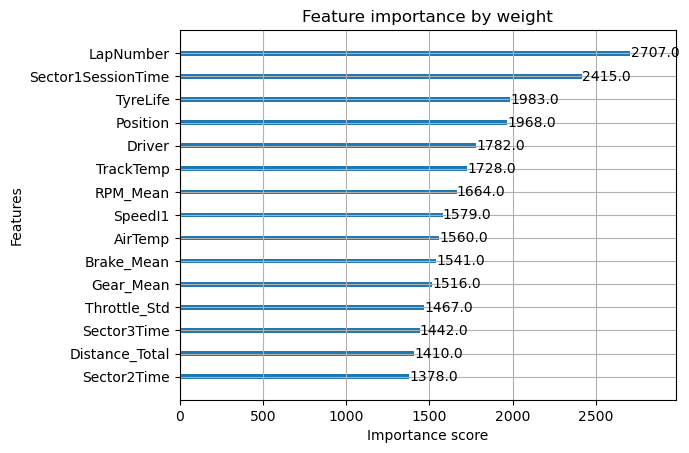


--- GAIN ---


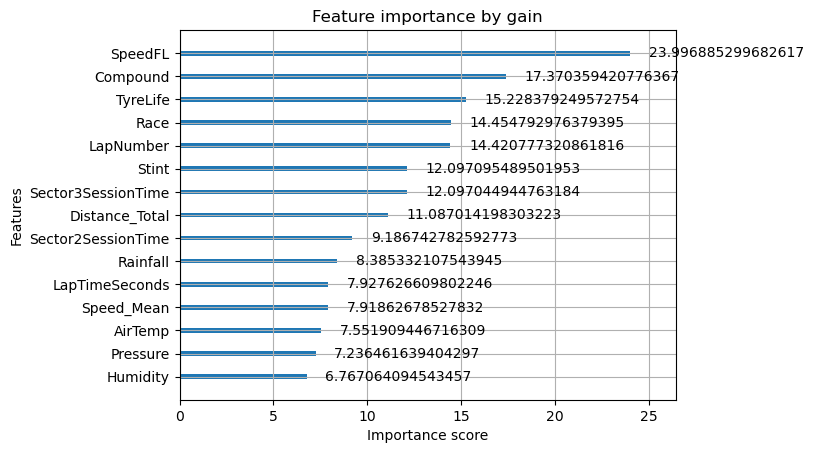


--- COVER ---


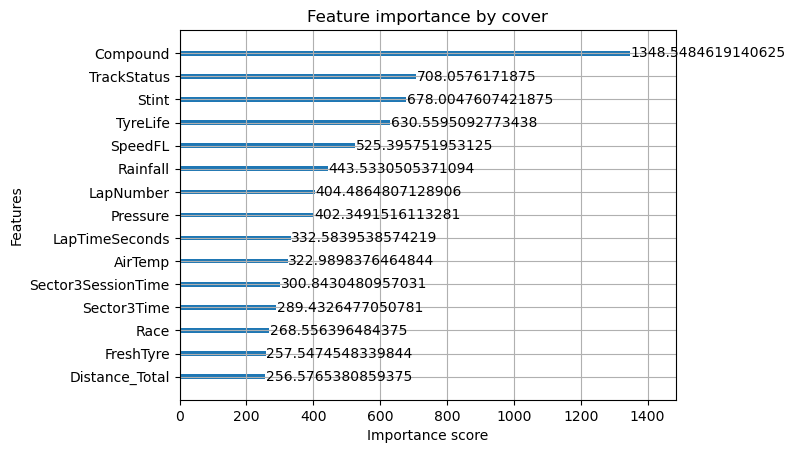

In [76]:
from xgboost import plot_importance

for t in ['weight', 'gain', 'cover']:
    print(f"\n--- {t.upper()} ---")
    plot_importance(best_xgb_cl, importance_type=t, max_num_features=15)
    plt.title(f"Feature importance by {t}")
    plt.show()

Find false positive/negative laps:

In [77]:
# Add predictions and true labels back to validation set
val_results = X_val_cl.copy()
val_results['TrueLabel'] = y_val_cl.values  # true pit/npit
val_results['PredLabel'] = y_val_pred_cl_best
val_results['Correct'] = (val_results['TrueLabel'] == val_results['PredLabel'])

In [78]:
# Reverse categorical encoding
for col in categorical_cols:
    val_results[col] = encoders[col].inverse_transform(val_results[col])

In [79]:
# Reverse standardization
val_results[numerical_cols] = scaler.inverse_transform(val_results[numerical_cols])

In [127]:
# Add LapsTilPit back in
val_results['LapsTilPit'] = val_df_with_laps_till_pit['LapsTilPit']

In [128]:
val_results.shape

(24206, 42)

In [129]:
val_results.iloc[600]

Driver                               SAI
Team                             Ferrari
Race                  Bahrain Grand Prix
Sector1Time                       30.851
Sector2Time                       41.959
Sector3Time                       23.727
Sector1SessionTime              6563.574
Sector2SessionTime              6605.533
Sector3SessionTime               6629.26
SpeedI1                            234.0
SpeedI2                            253.0
SpeedFL                            280.0
Stint                                2.0
LapNumber                           31.0
Position                             3.0
Compound                            HARD
TyreLife                            17.0
FreshTyre                              1
TrackStatus                            1
AirTemp                             18.0
Humidity                            49.0
Pressure                          1017.3
Rainfall                               0
TrackTemp                           22.6
WindSpeed       

In [130]:
# False Positives: Predicted 1 (pit soon), actually 0 (not pitting soon)
false_positives = val_results[(val_results['PredLabel'] == 1) & (val_results['TrueLabel'] == 0)]

# False Negatives: Predicted 0, actually 1
false_negatives = val_results[(val_results['PredLabel'] == 0) & (val_results['TrueLabel'] == 1)]

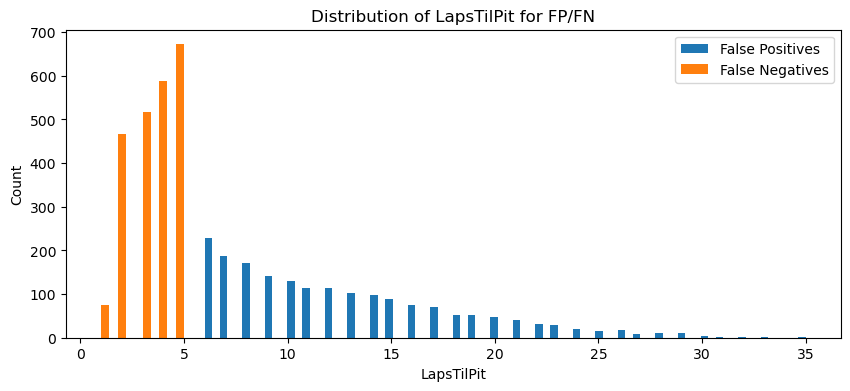

In [131]:
plt.figure(figsize=(10,4))
plt.hist(false_positives['LapsTilPit'], bins=80, label='False Positives')
plt.hist(false_negatives['LapsTilPit'], bins=10, label='False Negatives')
plt.xlabel('LapsTilPit')
plt.ylabel('Count')
plt.legend()
plt.title('Distribution of LapsTilPit for FP/FN')
plt.show()

In [132]:
# Mean TyreLife for FP/FN
print("False Positives: Mean TyreLife", false_positives['TyreLife'].mean())
print("False Negatives: Mean TyreLife", false_negatives['TyreLife'].mean())

False Positives: Mean TyreLife 25.952457264957264
False Negatives: Mean TyreLife 16.4993531694696


In [133]:
print('Stint Precision')
print(val_results.groupby('Stint')['Correct'].mean())
print('\nFalse Positives')
print(false_positives.groupby('Stint').size())
print('\nFalse Negatives')
print(false_negatives.groupby('Stint').size())

Stint Precision
Stint
1.0    0.753704
2.0    0.857237
3.0    0.868242
4.0    0.814241
5.0    0.917431
Name: Correct, dtype: float64

False Positives
Stint
1.0    952
2.0    693
3.0    138
4.0     87
5.0      2
dtype: int64

False Negatives
Stint
1.0    860
2.0    830
3.0    520
4.0     93
5.0     16
dtype: int64


In [134]:
print('Compound Precision')
print(val_results.groupby('Compound')['Correct'].mean())
print('\nFalse Positives')
print(false_positives.groupby('Compound').size())
print('\nFalse Negatives')
print(false_negatives.groupby('Compound').size())

Compound Precision
Compound
HARD      0.863267
MEDIUM    0.775709
SOFT      0.799653
Name: Correct, dtype: float64

False Positives
Compound
HARD       742
MEDIUM    1057
SOFT        73
dtype: int64

False Negatives
Compound
HARD      1127
MEDIUM     919
SOFT       273
dtype: int64


In [135]:
print('Rainfall Precision')
print(val_results.groupby('Rainfall')['Correct'].mean())
print('\nFalse Positives')
print(false_positives.groupby('Rainfall').size())
print('\nFalse Negatives')
print(false_negatives.groupby('Rainfall').size())

Rainfall Precision
Rainfall
0    0.828094
1    0.668449
Name: Correct, dtype: float64

False Positives
Rainfall
0    1840
1      32
dtype: int64

False Negatives
Rainfall
0    2289
1      30
dtype: int64


In [136]:
print('TrackStatus Precision')
print(val_results.groupby('TrackStatus')['Correct'].agg(['count', 'mean']))

TrackStatus Precision
             count      mean
TrackStatus                 
1            22841  0.825883
12             414  0.758454
124             89  0.966292
125             18  1.000000
1254            16  1.000000
126             38  0.657895
1264            15  1.000000
1267             9  1.000000
14              17  0.705882
16              17  0.823529
167             22  0.772727
21              32  0.718750
24              34  1.000000
26              35  0.514286
2671             1  1.000000
4              363  0.950413
41             146  0.938356
412              1  0.000000
6               26  0.192308
64              19  0.789474
671             43  0.883721
71              10  0.900000


In [137]:
precision_col = 'Rainfall'

print(f'{precision_col} Precision')
print(val_results.groupby(precision_col)['Correct'].mean())
print('\nFalse Positives')
print(false_positives.groupby(precision_col).size())
print('\nFalse Negatives')
print(false_negatives.groupby(precision_col).size())

Rainfall Precision
Rainfall
0    0.828094
1    0.668449
Name: Correct, dtype: float64

False Positives
Rainfall
0    1840
1      32
dtype: int64

False Negatives
Rainfall
0    2289
1      30
dtype: int64
